# Python for ML — NumPy, Vectorization & the ML Toolkit

## What This Notebook Is

The bridge between "Python programmer" and "ML practitioner."

You know Python. You've used sklearn.  
This notebook covers the **foundational layer that everything in ML is built on:**

- **NumPy** — the reason Python became the language of science
- **Vectorization** — thinking in arrays, not loops
- **Matplotlib** — visualization that reveals what's in your data
- **The ML-specific patterns** — random seeds, memory layout, broadcasting

**These aren't just useful — they're required.**  
Every sklearn model, every PyTorch tensor, every Pandas DataFrame  
is built on top of NumPy arrays.

## What We Cover

| Section | Topic |
|---|---|
| 1 | NumPy Arrays — the foundation of all ML |
| 2 | Array Operations & Broadcasting |
| 3 | Vectorization — eliminate your for-loops |
| 4 | Indexing & Masking — selecting data the NumPy way |
| 5 | Linear Algebra with NumPy |
| 6 | Random Numbers & Reproducibility |
| 7 | Matplotlib — visualization for ML |
| 8 | The ML Workflow in Code — end-to-end mini example |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

np.random.seed(42)

print("NumPy version:", np.__version__)
print()
print("The most important line in any ML notebook:")
print("  np.random.seed(42)")
print("  → makes random results reproducible")
print("  → always put this at the top")


NumPy version: 2.4.2

The most important line in any ML notebook:
  np.random.seed(42)
  → makes random results reproducible
  → always put this at the top


---
## Section 1 — NumPy Arrays: The Foundation

### Why NumPy?

Python lists are general-purpose — they can hold anything.  
NumPy arrays are specialized — they hold one dtype, stored in contiguous memory.

This makes NumPy operations **10–100× faster** than equivalent Python loops,  
because the actual computation is in compiled C/Fortran, not interpreted Python.

```python
# Python list: each element is a Python object (overhead per element)
[1, 2, 3, 4, 5]   # slow — element access involves Python interpreter

# NumPy array: all elements same type, packed in memory
np.array([1, 2, 3, 4, 5])   # fast — maps directly to CPU operations
```

### The dtype System

```
int8, int16, int32, int64
uint8, uint16, uint32, uint64     (unsigned)
float16, float32, float64 (=float)
bool, complex64, complex128, object
```

In ML:
- **float32** — default for neural network weights (half the memory of float64)
- **float64** — default for sklearn (precision matters for convex optimization)
- **int64** — labels, indices
- **uint8** — raw image pixel values (0–255)


In [2]:
print("=== NumPy Array Fundamentals ===")
print()

# ── Creating arrays ────────────────────────────────────────────────────────────
a1 = np.array([1, 2, 3, 4, 5])                    # from list
a2 = np.array([[1, 2, 3], [4, 5, 6]])             # 2D from nested list
a3 = np.zeros((3, 4))                              # zeros
a4 = np.ones((2, 3), dtype=np.float32)             # ones, specific dtype
a5 = np.eye(4)                                     # identity matrix
a6 = np.arange(0, 10, 0.5)                        # like range() but float steps
a7 = np.linspace(0, 1, 11)                        # 11 evenly spaced from 0 to 1

print("  Common array creators:")
print(f"  np.arange(0, 10, 2):    {np.arange(0, 10, 2)}")
print(f"  np.linspace(0, 1, 6):   {np.linspace(0, 1, 6).round(2)}")
print(f"  np.zeros((2,3)):\n{np.zeros((2,3))}")
print(f"  np.eye(3):\n{np.eye(3)}")
print()

# ── The most important attributes ─────────────────────────────────────────────
X = np.random.randn(1000, 20)   # typical ML dataset: 1000 samples, 20 features

print("  Array attributes (X = random 1000×20 dataset):")
print(f"  X.shape:   {X.shape}  ← (n_samples, n_features)")
print(f"  X.ndim:    {X.ndim}   ← number of dimensions")
print(f"  X.dtype:   {X.dtype}  ← float64 by default")
print(f"  X.size:    {X.size}   ← total number of elements")
print(f"  X.nbytes:  {X.nbytes:,} bytes = {X.nbytes/1024:.1f} KB")
print()

# ── dtype matters — memory and precision ──────────────────────────────────────
print("  dtype comparison:")
for dtype in [np.float64, np.float32, np.float16]:
    arr = np.ones((1000, 1000), dtype=dtype)
    print(f"  float{arr.itemsize*8}: {arr.nbytes/1024/1024:.1f} MB  "
          f"max={np.finfo(dtype).max:.2e}  eps={np.finfo(dtype).eps:.2e}")
print()

# ── Reshaping — critical for ML ─────────────────────────────────────────────
v = np.array([1, 2, 3, 4, 5, 6])
print(f"  v:                  {v}  shape={v.shape}")
print(f"  v.reshape(2,3):\n{v.reshape(2,3)}")
print(f"  v.reshape(-1,1):    shape={v.reshape(-1,1).shape}  ← column vector (-1=infer)")
print(f"  v.reshape(1,-1):    shape={v.reshape(1,-1).shape}  ← row vector")
print()
print("  sklearn always expects shape (n_samples, n_features):")
print("  If you have a 1D array: X.reshape(-1, 1)  ← one feature, many samples")
print("  If you have features:   X.reshape(1, -1)  ← one sample, many features")


=== NumPy Array Fundamentals ===

  Common array creators:
  np.arange(0, 10, 2):    [0 2 4 6 8]
  np.linspace(0, 1, 6):   [0.  0.2 0.4 0.6 0.8 1. ]
  np.zeros((2,3)):
[[0. 0. 0.]
 [0. 0. 0.]]
  np.eye(3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

  Array attributes (X = random 1000×20 dataset):
  X.shape:   (1000, 20)  ← (n_samples, n_features)
  X.ndim:    2   ← number of dimensions
  X.dtype:   float64  ← float64 by default
  X.size:    20000   ← total number of elements
  X.nbytes:  160,000 bytes = 156.2 KB

  dtype comparison:
  float64: 7.6 MB  max=1.80e+308  eps=2.22e-16
  float32: 3.8 MB  max=3.40e+38  eps=1.19e-07
  float16: 1.9 MB  max=6.55e+04  eps=9.77e-04

  v:                  [1 2 3 4 5 6]  shape=(6,)
  v.reshape(2,3):
[[1 2 3]
 [4 5 6]]
  v.reshape(-1,1):    shape=(6, 1)  ← column vector (-1=infer)
  v.reshape(1,-1):    shape=(1, 6)  ← row vector

  sklearn always expects shape (n_samples, n_features):
  If you have a 1D array: X.reshape(-1, 1)  ← one feature, many samples


---
## Section 2 — Array Operations & Broadcasting

### Element-wise Operations (the default)

```python
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

a + b   → [5, 7, 9]   # element-wise
a * b   → [4, 10, 18] # element-wise
a ** 2  → [1, 4, 9]   # element-wise
```

### Broadcasting — The Superpower

Broadcasting allows operations between arrays of **different shapes**,  
as long as their shapes are compatible.

```python
X = np.ones((100, 3))   # 100 samples, 3 features
mean = np.array([2, 3, 4])  # 1D array of length 3

X - mean   # → subtracts [2,3,4] from EVERY row of X (100 subtractions at once)
```

**Broadcasting rule:** Dimensions are compatible if they are equal, or one of them is 1.


In [3]:
print("=== Array Operations ===")
print()

a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.array([2.0, 0.5, 4.0, 1.0])

print("  Element-wise operations:")
print(f"  a + b   = {a + b}")
print(f"  a * b   = {a * b}")
print(f"  a / b   = {a / b}")
print(f"  a ** 2  = {a ** 2}")
print(f"  np.sqrt(a) = {np.sqrt(a).round(4)}")
print(f"  np.log(a)  = {np.log(a).round(4)}")
print()

# Statistical aggregations — critical for ML
X = np.random.randn(100, 5)
print("  Aggregation operations on X (100×5):")
print(f"  X.mean():         {X.mean():.4f}          ← grand mean")
print(f"  X.mean(axis=0):   {X.mean(axis=0).round(4)}  ← mean of each column (feature)")
print(f"  X.mean(axis=1)[:3]: {X.mean(axis=1)[:3].round(4)}  ← mean of each row (sample)")
print(f"  X.std(axis=0):    {X.std(axis=0).round(4)}")
print(f"  X.min(), X.max(): {X.min():.3f}, {X.max():.3f}")
print(f"  X.argmax():       {X.argmax()}  ← flat index of max element")
print()

# ── Broadcasting ──────────────────────────────────────────────────────────────
print("=== Broadcasting ===")

# Manual standardization (same as StandardScaler)
X_raw = np.array([[100, 2, 30],
                  [200, 3, 10],
                  [150, 5, 20],
                  [250, 1, 40]])
mean = X_raw.mean(axis=0)   # shape (3,)
std  = X_raw.std(axis=0)    # shape (3,)

# Broadcasting: (4,3) - (3,) → subtracts mean from every row
X_scaled = (X_raw - mean) / std

print(f"  X_raw  shape: {X_raw.shape}")
print(f"  mean   shape: {mean.shape}")
print(f"  X_scaled shape: {X_scaled.shape}  ← broadcasting worked!")
print()
print(f"  X_raw:\n{X_raw}")
print(f"  X_scaled (standardized):\n{X_scaled.round(3)}")
print()
print(f"  Verify: column means ≈ 0: {X_scaled.mean(axis=0).round(10)}")
print(f"  Verify: column stds  ≈ 1: {X_scaled.std(axis=0).round(10)}")
print()

# Outer product via broadcasting
u = np.array([1, 2, 3])     # shape (3,)
v = np.array([10, 20, 30])  # shape (3,)

# Reshape to (3,1) × (1,3) = (3,3)
outer = u.reshape(-1, 1) * v.reshape(1, -1)
print(f"  Outer product u @ v.T:\n{outer}")
print(f"  (Same as np.outer(u, v)):\n{np.outer(u, v)}")


=== Array Operations ===

  Element-wise operations:
  a + b   = [3.  2.5 7.  5. ]
  a * b   = [ 2.  1. 12.  4.]
  a / b   = [0.5  4.   0.75 4.  ]
  a ** 2  = [ 1.  4.  9. 16.]
  np.sqrt(a) = [1.     1.4142 1.7321 2.    ]
  np.log(a)  = [0.     0.6931 1.0986 1.3863]

  Aggregation operations on X (100×5):
  X.mean():         -0.0659          ← grand mean
  X.mean(axis=0):   [-0.1245  0.0129 -0.087  -0.1235 -0.0075]  ← mean of each column (feature)
  X.mean(axis=1)[:3]: [-0.2431  0.1681  0.0283]  ← mean of each row (sample)
  X.std(axis=0):    [0.9572 0.9878 1.1727 1.0332 0.988 ]
  X.min(), X.max(): -3.199, 3.603
  X.argmax():       126  ← flat index of max element

=== Broadcasting ===
  X_raw  shape: (4, 3)
  mean   shape: (3,)
  X_scaled shape: (4, 3)  ← broadcasting worked!

  X_raw:
[[100   2  30]
 [200   3  10]
 [150   5  20]
 [250   1  40]]
  X_scaled (standardized):
[[-1.342 -0.507  0.447]
 [ 0.447  0.169 -1.342]
 [-0.447  1.521 -0.447]
 [ 1.342 -1.183  1.342]]

  Verify: column

---
## Section 3 — Vectorization: Eliminate Your For-Loops

### The Golden Rule of ML Code

> **If you're writing a for-loop over samples, you're probably doing it wrong.**

Python for-loops are slow. NumPy operations in C are fast.  
The difference is often **100–1000×**.

```python
# SLOW: Python loop
for i in range(len(X)):
    y_pred[i] = w @ X[i] + b

# FAST: vectorized
y_pred = X @ w + b    # matrix multiplication does all samples at once
```

The key mental shift: think about **arrays**, not elements.


In [4]:
print("=== Vectorization ===")
print()

np.random.seed(0)
n = 100_000   # 100k samples
X = np.random.randn(n, 50)   # 100k samples, 50 features
w = np.random.randn(50)
b = 0.5

# ── Speed comparison ─────────────────────────────────────────────────────────
# Method 1: Python loop (never do this)
def predict_loop(X, w, b):
    y = np.zeros(len(X))
    for i in range(len(X)):
        y[i] = np.dot(X[i], w) + b
    return y

# Method 2: Vectorized (always do this)
def predict_vec(X, w, b):
    return X @ w + b

# Timing
t0 = time.perf_counter()
y_loop = predict_loop(X[:1000], w, b)   # only 1000 for the loop (too slow otherwise)
t1 = time.perf_counter()
y_vec  = predict_vec(X, w, b)           # all 100k
t2 = time.perf_counter()

time_loop_per_sample = (t1 - t0) / 1000
time_vec_per_sample  = (t2 - t1) / n
speedup = time_loop_per_sample / time_vec_per_sample

print(f"  n = {n:,} samples, {X.shape[1]} features")
print(f"  Loop (per sample):       {time_loop_per_sample*1e6:.2f} μs")
print(f"  Vectorized (per sample): {time_vec_per_sample*1e6:.4f} μs")
print(f"  Speedup:                 {speedup:.0f}×")
print()
print(f"  Results identical: {np.allclose(y_loop, y_vec[:1000])}")
print()

# ── Real-world vectorization examples ─────────────────────────────────────────
print("=== Vectorization Examples ===")
print()

X  = np.random.randn(1000, 10)
y  = np.random.randint(0, 2, 1000).astype(float)
w  = np.random.randn(10)

# 1. Manual MSE loss
y_pred = X @ w
mse    = np.mean((y - y_pred) ** 2)
rmse   = np.sqrt(mse)
print(f"  MSE:   {mse:.4f}")
print(f"  RMSE:  {rmse:.4f}")
print()

# 2. Manual R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2     = 1 - ss_res / ss_tot
print(f"  R² (manual vectorized): {r2:.4f}")
print()

# 3. Softmax (used in neural network output layers)
def softmax(logits):
    # Numerically stable version (subtract max before exp)
    exp = np.exp(logits - logits.max(axis=-1, keepdims=True))
    return exp / exp.sum(axis=-1, keepdims=True)

logits = np.array([[2.0, 1.0, 0.1],
                   [0.5, 2.5, 0.8]])
probs  = softmax(logits)
print(f"  Softmax input:\n{logits}")
print(f"  Softmax output:\n{probs.round(4)}")
print(f"  Row sums: {probs.sum(axis=1)}  ← should be 1.0")
print()

# 4. Batch matrix multiply — the core of neural networks
batch_size = 32
seq_len    = 10
d_model    = 64
X_batch    = np.random.randn(batch_size, seq_len, d_model)   # 3D!
W          = np.random.randn(d_model, d_model)

# This is what a linear layer in a transformer does to every position
out = X_batch @ W   # broadcasts over batch and seq dimensions
print(f"  Batch linear transform: ({batch_size}, {seq_len}, {d_model}) @ ({d_model}, {d_model})")
print(f"  Output shape: {out.shape}  ← same batch/seq dims, transformed features")


=== Vectorization ===

  n = 100,000 samples, 50 features
  Loop (per sample):       0.34 μs
  Vectorized (per sample): 0.0060 μs
  Speedup:                 58×

  Results identical: True

=== Vectorization Examples ===

  MSE:   11.6389
  RMSE:  3.4116

  R² (manual vectorized): -45.5557

  Softmax input:
[[2.  1.  0.1]
 [0.5 2.5 0.8]]
  Softmax output:
[[0.659  0.2424 0.0986]
 [0.1027 0.7587 0.1386]]
  Row sums: [1. 1.]  ← should be 1.0

  Batch linear transform: (32, 10, 64) @ (64, 64)
  Output shape: (32, 10, 64)  ← same batch/seq dims, transformed features


---
## Section 4 — Indexing & Masking

### Four Ways to Index NumPy Arrays

```python
a = np.array([10, 20, 30, 40, 50])

# 1. Basic:     a[2] → 30
# 2. Slice:     a[1:4] → [20, 30, 40]
# 3. Fancy:     a[[0, 2, 4]] → [10, 30, 50]  (list of indices)
# 4. Boolean:   a[a > 25] → [30, 40, 50]     (mask)
```

Boolean masking is essential for data filtering in ML pipelines.


In [5]:
print("=== NumPy Indexing ===")
print()

np.random.seed(1)
X = np.random.randn(10, 4)
y = np.array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0])

print(f"  X shape: {X.shape}, y: {y}")
print()

# ── Basic and slice indexing ───────────────────────────────────────────────────
print("  Basic indexing:")
print(f"  X[0]:        {X[0].round(3)}  ← first row (sample)")
print(f"  X[:, 0]:     {X[:, 0].round(3)}  ← first column (feature)")
print(f"  X[0, 2]:     {X[0, 2]:.3f}  ← row 0, col 2")
print(f"  X[2:5, 1:3]: shape {X[2:5, 1:3].shape}  ← rows 2-4, cols 1-2")
print()

# ── Fancy indexing ────────────────────────────────────────────────────────────
print("  Fancy indexing:")
selected_rows = [0, 3, 7]
print(f"  X[[0,3,7]]: \n{X[selected_rows].round(3)}  ← select specific samples")
print()

# ── Boolean masking — the ML workhorse ────────────────────────────────────────
print("  Boolean masking (critical for data filtering):")
# Select all positive class samples
pos_mask = y == 1
neg_mask = y == 0
print(f"  y:           {y}")
print(f"  y == 1 mask: {pos_mask.astype(int)}")
print(f"  X_positive (y=1) shape: {X[pos_mask].shape}")
print(f"  X_negative (y=0) shape: {X[neg_mask].shape}")
print()

# Filter rows where first feature is positive
feat0_pos = X[:, 0] > 0
print(f"  Samples with feature_0 > 0: {feat0_pos.sum()} of {len(X)}")
print(f"  Their y labels: {y[feat0_pos]}")
print()

# ── np.where — conditional selection ────────────────────────────────────────
print("  np.where (conditional assignment):")
# Apply ReLU to entire array
X_relu  = np.where(X > 0, X, 0)
print(f"  X[:3, :2]:\n{X[:3, :2].round(3)}")
print(f"  ReLU(X)[:3, :2]:\n{X_relu[:3, :2].round(3)}")
print()

# ── np.argsort — get sorted indices ─────────────────────────────────────────
print("  np.argsort (rankings):")
scores = np.array([0.82, 0.91, 0.78, 0.95, 0.88])
sorted_idx = np.argsort(scores)[::-1]   # descending
print(f"  Scores:  {scores}")
print(f"  Ranking: {sorted_idx}")
print(f"  Top 3:   {scores[sorted_idx[:3]]}")
print()

# ── Train/test split without sklearn ────────────────────────────────────────
print("  Manual train/test split:")
n = len(X)
indices  = np.arange(n)
np.random.shuffle(indices)
split    = int(0.8 * n)
tr_idx   = indices[:split]
te_idx   = indices[split:]
X_tr, X_te = X[tr_idx], X[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]
print(f"  Train: {X_tr.shape}  Test: {X_te.shape}")


=== NumPy Indexing ===

  X shape: (10, 4), y: [0 1 1 0 1 0 0 1 1 0]

  Basic indexing:
  X[0]:        [ 1.624 -0.612 -0.528 -1.073]  ← first row (sample)
  X[:, 0]:     [ 1.624  0.865  0.319 -0.322 -0.172 -1.101  0.901 -0.268 -0.687 -1.117]  ← first column (feature)
  X[0, 2]:     -0.528  ← row 0, col 2
  X[2:5, 1:3]: shape (3, 2)  ← rows 2-4, cols 1-2

  Fancy indexing:
  X[[0,3,7]]: 
[[ 1.624 -0.612 -0.528 -1.073]
 [-0.322 -0.384  1.134 -1.1  ]
 [-0.268  0.53  -0.692 -0.397]]  ← select specific samples

  Boolean masking (critical for data filtering):
  y:           [0 1 1 0 1 0 0 1 1 0]
  y == 1 mask: [0 1 1 0 1 0 0 1 1 0]
  X_positive (y=1) shape: (5, 4)
  X_negative (y=0) shape: (5, 4)

  Samples with feature_0 > 0: 4 of 10
  Their y labels: [0 1 1 0]

  np.where (conditional assignment):
  X[:3, :2]:
[[ 1.624 -0.612]
 [ 0.865 -2.302]
 [ 0.319 -0.249]]
  ReLU(X)[:3, :2]:
[[1.624 0.   ]
 [0.865 0.   ]
 [0.319 0.   ]]

  np.argsort (rankings):
  Scores:  [0.82 0.91 0.78 0.95 0.88]


---
## Section 5 — Linear Algebra with NumPy

The operations in every ML algorithm come down to matrix math.  
Knowing these NumPy functions means you can read and implement papers.

```python
# The three most important operations:
np.dot(a, b)     or  a @ b    # dot product / matrix multiply
np.linalg.norm(v)              # vector/matrix norm
np.linalg.solve(A, b)          # solve Ax = b (better than inv(A) @ b)
```


In [6]:
print("=== Linear Algebra with NumPy ===")
print()

# ── Matrix operations ─────────────────────────────────────────────────────────
A = np.array([[2, 1], [1, 3]], dtype=float)
B = np.array([[1, 0], [2, 1]], dtype=float)
v = np.array([3, 4], dtype=float)

print("  Matrix operations:")
print(f"  A @ B (matrix multiply):\n{A @ B}")
print(f"  A.T (transpose):\n{A.T}")
print(f"  np.linalg.det(A): {np.linalg.det(A):.2f}")
print(f"  np.linalg.inv(A):\n{np.linalg.inv(A)}")
print(f"  A @ v: {A @ v}  ← matrix-vector product")
print()

# ── Solving linear systems ───────────────────────────────────────────────────
print("  Solving Ax = b:")
b_vec = np.array([5, 7], dtype=float)
# np.linalg.solve is more numerically stable than np.linalg.inv(A) @ b
x = np.linalg.solve(A, b_vec)
print(f"  A = {A.tolist()}")
print(f"  b = {b_vec}")
print(f"  x = {x}  (solve Ax = b)")
print(f"  Verify A @ x = {A @ x}  ≈ b = {b_vec}")
print()

# ── The OLS Normal Equation ───────────────────────────────────────────────────
print("  OLS = solve (X^T X) w = X^T y:")
np.random.seed(0)
X_data = np.random.randn(100, 5)
true_w = np.array([1.5, -2.0, 0.5, 1.0, -1.0])
y_data = X_data @ true_w + 0.1 * np.random.randn(100)

X_b = np.column_stack([np.ones(100), X_data])
A_ols = X_b.T @ X_b
b_ols = X_b.T @ y_data
w_ols = np.linalg.solve(A_ols, b_ols)
print(f"  True weights:    {true_w}")
print(f"  Learned weights: {w_ols[1:].round(4)}")
print()

# ── Eigendecomposition (PCA uses this) ────────────────────────────────────────
print("  Eigendecomposition (used in PCA):")
X_centered = X_data - X_data.mean(axis=0)
cov_matrix = (X_centered.T @ X_centered) / (len(X_centered) - 1)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh sorts ascending — reverse for descending
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print(f"  Covariance matrix shape: {cov_matrix.shape}")
print(f"  Eigenvalues: {eigenvalues.round(4)}")
print(f"  % variance explained: {(eigenvalues / eigenvalues.sum() * 100).round(1)}")
print()

# ── SVD (Singular Value Decomposition) ───────────────────────────────────────
print("  SVD (backbone of PCA, matrix factorization, LSA):")
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
print(f"  U:  {U.shape}  ← left singular vectors")
print(f"  S:  {S.shape}  ← singular values (√eigenvalues × (n-1))")
print(f"  Vt: {Vt.shape} ← right singular vectors (principal components)")
print(f"  Singular values: {S.round(3)}")

# Reconstruction from top-k components
k = 3
X_reconstructed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
reconstruction_error = np.mean((X_centered - X_reconstructed)**2)
print(f"  Reconstruction with k={k}: MSE = {reconstruction_error:.4f}")


=== Linear Algebra with NumPy ===

  Matrix operations:
  A @ B (matrix multiply):
[[4. 1.]
 [7. 3.]]
  A.T (transpose):
[[2. 1.]
 [1. 3.]]
  np.linalg.det(A): 5.00
  np.linalg.inv(A):
[[ 0.6 -0.2]
 [-0.2  0.4]]
  A @ v: [10. 15.]  ← matrix-vector product

  Solving Ax = b:
  A = [[2.0, 1.0], [1.0, 3.0]]
  b = [5. 7.]
  x = [1.6 1.8]  (solve Ax = b)
  Verify A @ x = [5. 7.]  ≈ b = [5. 7.]

  OLS = solve (X^T X) w = X^T y:
  True weights:    [ 1.5 -2.   0.5  1.  -1. ]
  Learned weights: [ 1.503  -1.993   0.5213  0.9981 -1.0054]

  Eigendecomposition (used in PCA):
  Covariance matrix shape: (5, 5)
  Eigenvalues: [1.211  1.1595 1.0467 0.8186 0.7544]
  % variance explained: [24.3 23.2 21.  16.4 15.1]

  SVD (backbone of PCA, matrix factorization, LSA):
  U:  (100, 5)  ← left singular vectors
  S:  (5,)  ← singular values (√eigenvalues × (n-1))
  Vt: (5, 5) ← right singular vectors (principal components)
  Singular values: [10.949 10.714 10.179  9.003  8.642]
  Reconstruction with k=3: MSE

---
## Section 6 — Random Numbers & Reproducibility

### The Most Important Line in Any ML Script

```python
np.random.seed(42)
```

Without this, every run gives different results.  
With this, results are reproducible — anyone running your code gets the same numbers.

### Seeding at Multiple Levels

Modern ML code needs seeds at multiple levels:
```python
import numpy as np
import random

np.random.seed(42)     # NumPy operations
random.seed(42)        # Python's random module

# For PyTorch (when you get there):
# import torch
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)
```


In [7]:
print("=== Random Numbers & Reproducibility ===")
print()

# ── Why seeds matter ──────────────────────────────────────────────────────────
print("  Without seed — different each run:")
for _ in range(3):
    print(f"    {np.random.randn(4).round(3)}")
print()

np.random.seed(99)
print("  With seed=99 — always the same:")
for _ in range(3):
    np.random.seed(99)   # reset each iteration for demo
    print(f"    {np.random.randn(4).round(3)}")
print()

# ── Random distributions used in ML ─────────────────────────────────────────
np.random.seed(42)
print("  Random distributions used in ML:")
print(f"  Normal (0,1):    {np.random.randn(5).round(3)}  ← weight init (Xavier)")
print(f"  Normal(mu,sigma):{np.random.normal(5, 2, 5).round(3)}  ← synthetic features")
print(f"  Uniform [0,1]:   {np.random.uniform(0, 1, 5).round(3)}")
print(f"  Integers [0,10): {np.random.randint(0, 10, 5)}  ← labels, sampling")
print(f"  Bernoulli(0.3):  {np.random.binomial(1, 0.3, 5)}  ← dropout masks")
print(f"  Choice:          {np.random.choice([10,20,30,40,50], 3, replace=False)}")
print()

# ── Shuffling ────────────────────────────────────────────────────────────────
print("  Shuffling (critical for mini-batch training):")
data = np.arange(10)
print(f"  Original: {data}")

# shuffle in-place
shuffled = data.copy()
np.random.shuffle(shuffled)
print(f"  Shuffled: {shuffled}")

# permutation returns new array — better when you need to shuffle X and y together
indices = np.random.permutation(len(data))
print(f"  Permuted indices: {indices}")
print(f"  data[indices]: {data[indices]}")
print()

# ── Proper way to shuffle X and y together ────────────────────────────────────
print("  Shuffle X and y together (always use same indices!):")
X_ex = np.arange(20).reshape(10, 2)
y_ex = np.array([0,1,1,0,1,0,0,1,1,0])

np.random.seed(5)
idx = np.random.permutation(len(X_ex))
X_shuffled = X_ex[idx]
y_shuffled = y_ex[idx]

print(f"  Original y: {y_ex}")
print(f"  Shuffled y: {y_shuffled}")
print(f"  Indices:    {idx}")
print(f"  X_shuffled[0] = {X_shuffled[0]}  (was row {idx[0]})")
print()

# ── Using Generator (newer API) ───────────────────────────────────────────────
print("  Modern numpy Generator API (preferred for new code):")
rng = np.random.default_rng(seed=42)   # reproducible but independent of global state
sample = rng.standard_normal(5)
print(f"  rng.standard_normal(5): {sample.round(3)}")
print("  Use rng.* to avoid global state contamination in library code")


=== Random Numbers & Reproducibility ===

  Without seed — different each run:
    [-1.55   0.417 -0.944  0.238]
    [-1.406 -0.59  -0.11  -1.661]
    [ 0.115 -0.379 -1.742 -1.303]

  With seed=99 — always the same:
    [-0.142  2.057  0.283  1.33 ]
    [-0.142  2.057  0.283  1.33 ]
    [-0.142  2.057  0.283  1.33 ]

  Random distributions used in ML:
  Normal (0,1):    [ 0.497 -0.138  0.648  1.523 -0.234]  ← weight init (Xavier)
  Normal(mu,sigma):[4.532 8.158 6.535 4.061 6.085]  ← synthetic features
  Uniform [0,1]:   [0.182 0.183 0.304 0.525 0.432]
  Integers [0,10): [0 9 2 6 3]  ← labels, sampling
  Bernoulli(0.3):  [0 0 0 0 0]  ← dropout masks
  Choice:          [50 30 20]

  Shuffling (critical for mini-batch training):
  Original: [0 1 2 3 4 5 6 7 8 9]
  Shuffled: [0 5 2 6 3 7 4 1 8 9]
  Permuted indices: [4 8 1 3 0 5 2 9 7 6]
  data[indices]: [4 8 1 3 0 5 2 9 7 6]

  Shuffle X and y together (always use same indices!):
  Original y: [0 1 1 0 1 0 0 1 1 0]
  Shuffled y: [0 0 1 1 

---
## Section 7 — Matplotlib: Visualization for ML

### Why Visualization Matters

> "A picture is worth a thousand metrics."

Before modeling: visualize your data — see distributions, correlations, outliers.  
During modeling: plot learning curves — see if training is healthy.  
After modeling: plot predictions vs actuals — see where the model fails.

### The 4 Plots Every ML Engineer Needs

| Plot | Use |
|---|---|
| `scatter` | Feature correlations, predictions vs actuals |
| `hist` | Target/feature distributions, residuals |
| `plot` | Learning curves, loss curves |
| `imshow` | Confusion matrices, correlation heatmaps |


/var/folders/q1/9498s9914m31_cnj__snl5xm0000gn/T/ipykernel_56839/1392953372.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


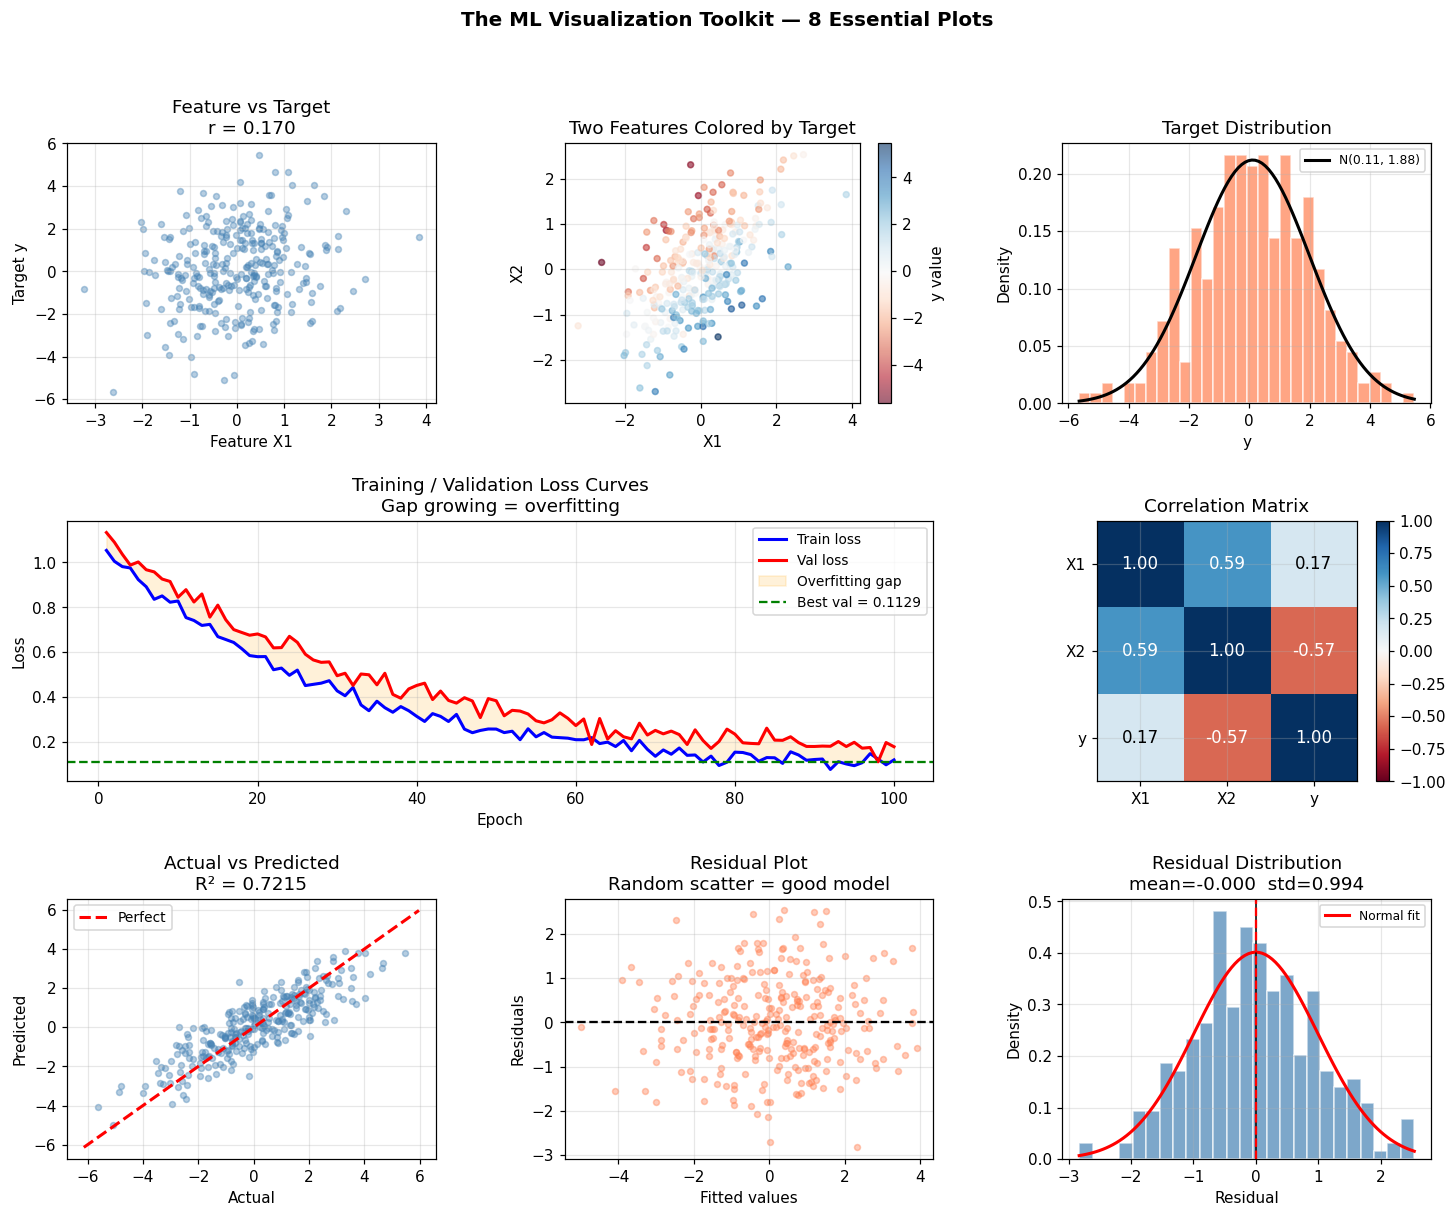

In [8]:
from scipy.stats import norm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from typing import cast

np.random.seed(42)

# Generate a realistic ML dataset for visualization
n = 300
X1 = np.random.normal(0, 1, n)
X2 = 0.6 * X1 + np.random.normal(0, 0.8, n)
y  = 1.5 * X1 - 2.0 * X2 + np.random.normal(0, 1, n)

# Simulate training history
epochs    = np.arange(1, 101)
train_loss = 1.0 * np.exp(-0.035 * epochs) + 0.08 + 0.02 * np.random.randn(100)
val_loss   = 1.0 * np.exp(-0.030 * epochs) + 0.12 + 0.03 * np.random.randn(100)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Scatter: Feature vs Target ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(X1, y, alpha=0.4, s=15, color='steelblue')
r1 = np.corrcoef(X1, y)[0, 1]
ax1.set_xlabel('Feature X1')
ax1.set_ylabel('Target y')
ax1.set_title(f'Feature vs Target\nr = {r1:.3f}')

# ── 2. Scatter with color encoding ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(X1, X2, c=y, cmap='RdBu', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax2, label='y value')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_title('Two Features Colored by Target')

# ── 3. Histogram: Distribution ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(y, bins=30, color='coral', alpha=0.7, edgecolor='white', density=True)
mu, sigma = y.mean(), y.std()
x_norm = np.linspace(y.min(), y.max(), 100)

ax3.plot(x_norm, norm.pdf(x_norm, mu, sigma), 'k-', lw=2, label=f'N({mu:.2f}, {sigma:.2f})')
ax3.set_xlabel('y')
ax3.set_ylabel('Density')
ax3.set_title('Target Distribution')
ax3.legend(fontsize=8)

# ── 4. Learning curves ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(epochs, train_loss, 'b-', lw=2, label='Train loss')
ax4.plot(epochs, val_loss,   'r-', lw=2, label='Val loss')
ax4.fill_between(epochs, train_loss, val_loss, alpha=0.15, color='orange',
                label='Overfitting gap')
ax4.axhline(val_loss.min(), color='green', ls='--', lw=1.5,
            label=f'Best val = {val_loss.min():.4f}')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.set_title('Training / Validation Loss Curves\nGap growing = overfitting')
ax4.legend(fontsize=9)

# ── 5. Correlation heatmap ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
data_matrix = np.column_stack([X1, X2, y])
corr = cast(np.ndarray, np.corrcoef(data_matrix.T))
im = ax5.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax5)
ax5.set_xticks([0,1,2])
ax5.set_yticks([0,1,2])
ax5.set_xticklabels(['X1','X2','y'])
ax5.set_yticklabels(['X1','X2','y'])
for i in range(3):
    for j in range(3):
        ax5.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if abs(corr[i,j]) > 0.5 else 'black')
ax5.set_title('Correlation Matrix')

# ── 6. Actual vs Predicted ────────────────────────────────────────────────────

X_feat  = np.column_stack([X1, X2])
scaler  = StandardScaler().fit(X_feat)
X_sc    = scaler.transform(X_feat)
model   = Ridge(alpha=1.0).fit(X_sc, y)
y_pred  = model.predict(X_sc)
resids  = y - y_pred

ax6 = fig.add_subplot(gs[2, 0])
ax6.scatter(y, y_pred, alpha=0.4, s=15, color='steelblue')
lim = [y.min()-0.5, y.max()+0.5]
ax6.plot(lim, lim, 'r--', lw=2, label='Perfect')
r2 = 1 - np.sum(resids**2) / np.sum((y - y.mean())**2)
ax6.set_xlabel('Actual')
ax6.set_ylabel('Predicted')
ax6.set_title(f'Actual vs Predicted\nR² = {r2:.4f}')
ax6.legend(fontsize=9)

# ── 7. Residuals ──────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
ax7.scatter(y_pred, resids, alpha=0.4, s=15, color='coral')
ax7.axhline(0, color='k', lw=1.5, ls='--')
ax7.set_xlabel('Fitted values')
ax7.set_ylabel('Residuals')
ax7.set_title('Residual Plot\nRandom scatter = good model')

# ── 8. Residual histogram ─────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.hist(resids, bins=25, color='steelblue', alpha=0.7, edgecolor='white', density=True)
x_r = np.linspace(resids.min(), resids.max(), 100)
ax8.plot(x_r, norm.pdf(x_r, resids.mean(), resids.std()), 'r-', lw=2, label='Normal fit')
ax8.axvline(0, color='k', lw=1)
ax8.axvline(resids.mean(), color='red', ls='--', lw=1.5)
ax8.set_xlabel('Residual')
ax8.set_ylabel('Density')
ax8.set_title(f'Residual Distribution\nmean={resids.mean():.3f}  std={resids.std():.3f}')
ax8.legend(fontsize=8)

plt.suptitle('The ML Visualization Toolkit — 8 Essential Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 8 — The ML Workflow End-to-End

Putting it all together: implement a complete ML pipeline using **only NumPy**  
(no sklearn) — so you can see exactly what happens under the hood.

This is gradient descent linear regression from scratch:
every step using what we've learned in this notebook.


=== End-to-End ML in NumPy ===

  Data: 200 samples, 4 features
  True weights: [ 2.  -1.5  0.8 -0.5]

  Train: (160, 4)  Test: (40, 4)

  Scaled X_tr mean: [-0.  0. -0.  0.]  ← should be ~0
  Scaled X_tr std:  [1. 1. 1. 1.]   ← should be ~1

  Training complete (200 epochs)
  True weights:    [ 2.  -1.5  0.8 -0.5]
  Learned weights: [ 1.7799 -1.4952  0.842  -0.5042]
  Final train R²:  0.9660
  Final val   R²:  0.9715



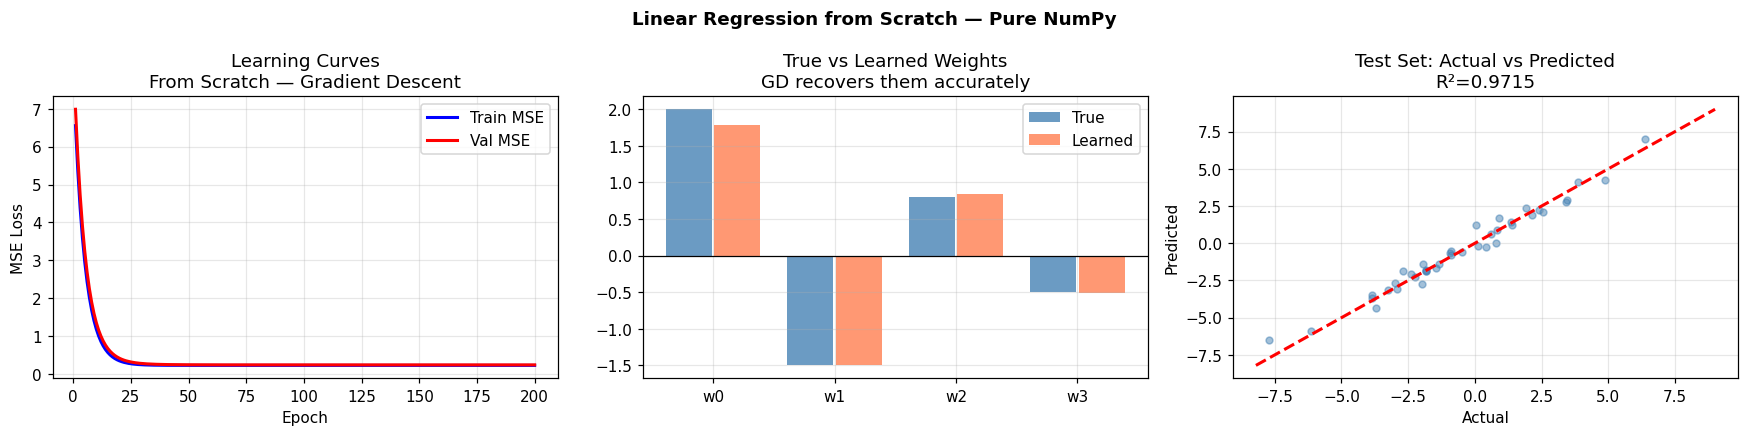

In [9]:
np.random.seed(42)
print("=== End-to-End ML in NumPy ===")
print()

# ── 1. Generate data ──────────────────────────────────────────────────────────
n, d = 200, 4
X = np.random.randn(n, d)
true_w = np.array([2.0, -1.5, 0.8, -0.5])
y = X @ true_w + np.random.randn(n) * 0.5   # linear + noise
print(f"  Data: {n} samples, {d} features")
print(f"  True weights: {true_w}")
print()

# ── 2. Train/test split (manual) ─────────────────────────────────────────────
idx    = np.random.permutation(n)
split  = int(0.8 * n)
X_tr, X_te = X[idx[:split]], X[idx[split:]]
y_tr, y_te = y[idx[:split]], y[idx[split:]]
print(f"  Train: {X_tr.shape}  Test: {X_te.shape}")
print()

# ── 3. Normalize (StandardScaler logic) ──────────────────────────────────────
mu  = X_tr.mean(axis=0)
std = X_tr.std(axis=0) + 1e-8       # add epsilon to avoid division by zero
X_tr_sc = (X_tr - mu) / std          # fit on train
X_te_sc = (X_te - mu) / std          # transform test (same mu/std!)
print(f"  Scaled X_tr mean: {X_tr_sc.mean(axis=0).round(4)}  ← should be ~0")
print(f"  Scaled X_tr std:  {X_tr_sc.std(axis=0).round(4)}   ← should be ~1")
print()

# ── 4. Gradient descent ──────────────────────────────────────────────────────
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

# Initialize weights
w = np.zeros(d)
b = 0.0
lr = 0.05
epochs = 200
history = {'train_loss': [], 'val_loss': [], 'train_r2': [], 'val_r2': []}

for epoch in range(epochs):
    # Forward pass
    y_pred_tr = X_tr_sc @ w + b

    # Compute gradients (vectorized — no loops!)
    residuals = y_pred_tr - y_tr
    grad_w = (2 / len(X_tr_sc)) * (X_tr_sc.T @ residuals)   # (d,) vector
    grad_b = (2 / len(X_tr_sc)) * residuals.sum()             # scalar

    # Update weights
    w -= lr * grad_w
    b -= lr * grad_b

    # Track metrics
    y_pred_te = X_te_sc @ w + b
    history['train_loss'].append(mse_loss(y_tr,  y_pred_tr))
    history['val_loss'].append(  mse_loss(y_te,  y_pred_te))
    history['train_r2'].append(  r2_score(y_tr,  y_pred_tr))
    history['val_r2'].append(    r2_score(y_te,  y_pred_te))

# ── 5. Results ────────────────────────────────────────────────────────────────
y_pred_final = X_te_sc @ w + b
print(f"  Training complete ({epochs} epochs)")
print(f"  True weights:    {true_w}")
print(f"  Learned weights: {w.round(4)}")
print(f"  Final train R²:  {history['train_r2'][-1]:.4f}")
print(f"  Final val   R²:  {history['val_r2'][-1]:.4f}")
print()

# ── 6. Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Learning curves
epochs_arr = np.arange(1, epochs + 1)
axes[0].plot(epochs_arr, history['train_loss'], 'b-', lw=2, label='Train MSE')
axes[0].plot(epochs_arr, history['val_loss'],   'r-', lw=2, label='Val MSE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Learning Curves\nFrom Scratch — Gradient Descent')
axes[0].legend()

# Weight convergence
weight_labels = [f'w{i} (true={true_w[i]})' for i in range(d)]
x_pos = np.arange(d)
axes[1].bar(x_pos - 0.2, true_w,  0.38, label='True',    color='steelblue', alpha=0.8)
axes[1].bar(x_pos + 0.2, w,       0.38, label='Learned',  color='coral',    alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'w{i}' for i in range(d)])
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_title('True vs Learned Weights\nGD recovers them accurately')
axes[1].legend()

# Actual vs predicted
axes[2].scatter(y_te, y_pred_final, alpha=0.5, s=20, color='steelblue')
lim = [y.min()-0.5, y.max()+0.5]
axes[2].plot(lim, lim, 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test Set: Actual vs Predicted\nR²={r2_score(y_te, y_pred_final):.4f}')

plt.suptitle('Linear Regression from Scratch — Pure NumPy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Summary — Python for ML

### The NumPy Fundamentals Checklist

```python
# Creating arrays
np.array([...])          np.zeros((n, m))      np.ones((n, m))
np.arange(start, stop)   np.linspace(a, b, n)  np.random.randn(n, m)

# The key attributes
X.shape    X.ndim    X.dtype    X.size    X.nbytes

# Reshaping
X.reshape(-1, 1)   X.reshape(1, -1)   X.flatten()

# Indexing
X[5]        X[2:8]      X[:, 0]      X[mask]    X[[0,3,7]]

# Math
X @ w          np.dot(a, b)      np.linalg.solve(A, b)
X.mean(axis=0) X.std(axis=0)     np.sqrt(X)    np.log1p(X)
np.argmax(X)   np.argsort(X)     np.where(cond, a, b)

# Always do these
np.random.seed(42)       # reproducibility
scaler.fit(X_train)      # fit on train
scaler.transform(X_test) # transform test (same parameters)
```

### The Golden Rules

1. **Think in arrays** — if you're writing `for i in range(len(X))`, stop
2. **Fit on train, transform both** — never fit your scaler on test data
3. **Set random seeds** — `np.random.seed(42)` at the top of every script
4. **Use `float32` for large arrays** — half the memory of `float64`
5. **Check shapes constantly** — `print(X.shape)` is your best debugging tool

### What's Next

- `numpy_pandas.ipynb` — Pandas builds on NumPy for tabular data
- `eda.ipynb` — systematic data exploration with visualization
- The regression notebooks — now the code will make complete sense
